In [41]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [42]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [43]:
NUTS2 = 'Thessaly'
YEAR = '2024'

In [44]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

In [45]:
df.head()

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,21.15549,39.67943,0,2024-05-02,EL61,2024,5,2024-05-02,39.680832,21.157571,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,2024-05-02,39.680832,21.157571,14703.0,13886.0,2024-05-02,39.650181,21.150097,2024-05-01,2024-05-01,1.283924
1,21.15549,39.67943,0,2024-05-03,EL61,2024,5,2024-05-02,39.680832,21.157571,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,2024-05-03,39.680832,21.157571,14703.0,13675.0,2024-05-03,39.650181,21.150097,2024-05-02,2024-05-02,0.000000
2,21.15549,39.67943,0,2024-05-04,EL61,2024,5,2024-05-04,39.680832,21.157571,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,2024-05-04,39.680832,21.157571,14703.0,13675.0,2024-05-04,39.650181,21.150097,2024-05-03,2024-05-03,0.521945
3,21.15549,39.67943,0,2024-05-05,EL61,2024,5,2024-05-05,39.680832,21.157571,0.629135,0.292248,-0.546083,-0.292248,0.562226,0.228036,-0.494274,-0.228036,0.054024,0.085745,0.041833,0.085745,2024-05-05,39.680832,21.157571,14703.0,13902.0,2024-05-05,39.650181,21.150097,2024-05-04,2024-05-04,0.000000
4,21.15549,39.67943,0,2024-05-06,EL61,2024,5,2024-05-05,39.680832,21.157571,0.629135,0.292248,-0.546083,-0.292248,0.562226,0.228036,-0.494274,-0.228036,0.054024,0.085745,0.041833,0.085745,2024-05-06,39.680832,21.157571,14744.0,13902.0,2024-05-06,39.650181,21.150097,2024-05-05,2024-05-05,0.000000


<Axes: >

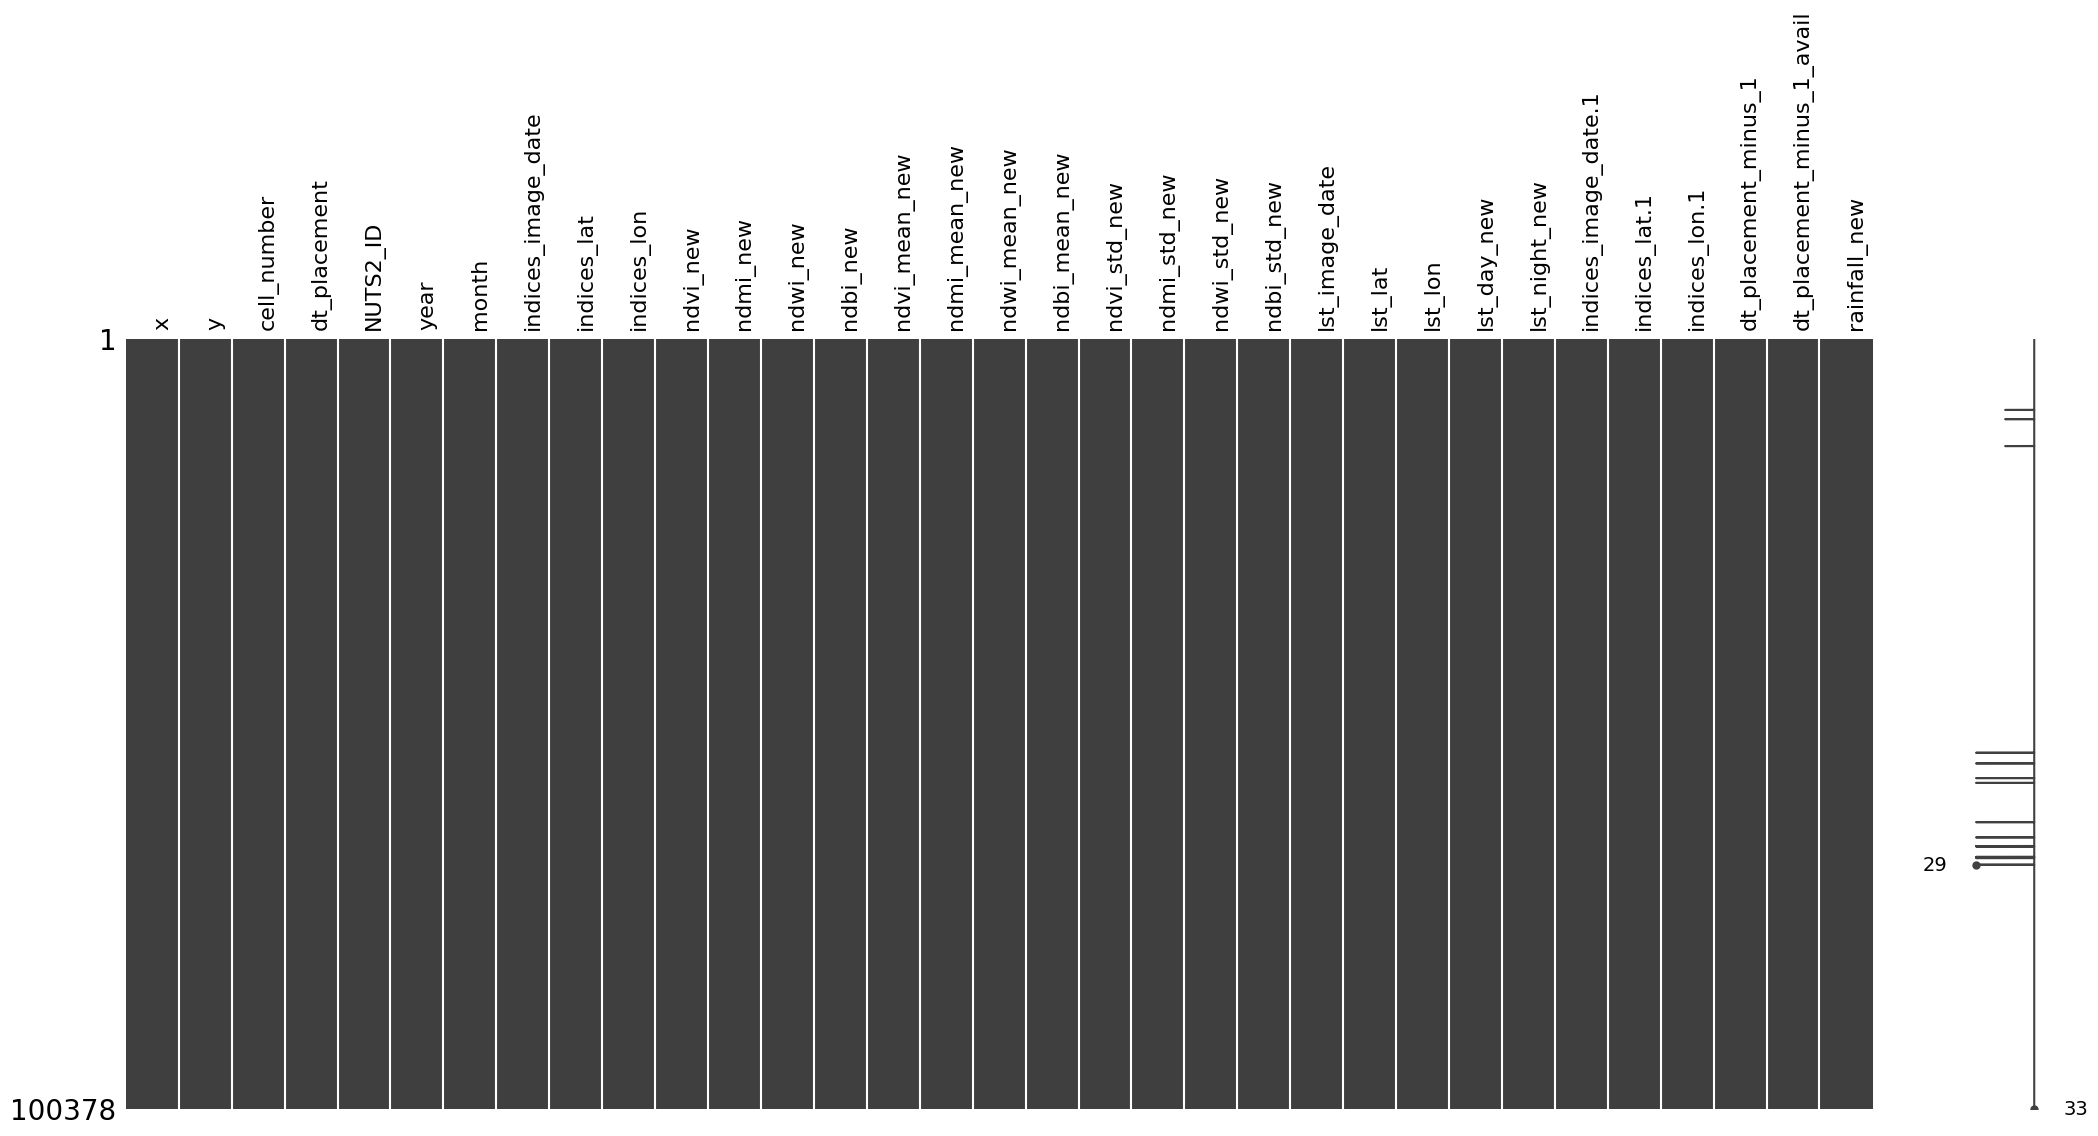

In [46]:
msno.matrix(df, label_rotation=90)

In [47]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)

In [48]:
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)

In [49]:
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [50]:
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [51]:
df

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_day,lst_night,rainfall_image_date,rainfall
0,21.15549,39.67943,0,2024-05-02,EL61,2024,5,2024-05-02,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,2024-05-02,14703.0,13886.0,2024-05-01,1.283924
1,21.15549,39.67943,0,2024-05-03,EL61,2024,5,2024-05-02,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,2024-05-03,14703.0,13675.0,2024-05-02,0.000000
2,21.15549,39.67943,0,2024-05-04,EL61,2024,5,2024-05-04,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,2024-05-04,14703.0,13675.0,2024-05-03,0.521945
3,21.15549,39.67943,0,2024-05-05,EL61,2024,5,2024-05-05,0.629135,0.292248,-0.546083,-0.292248,0.562226,0.228036,-0.494274,-0.228036,0.054024,0.085745,0.041833,0.085745,2024-05-05,14703.0,13902.0,2024-05-04,0.000000
4,21.15549,39.67943,0,2024-05-06,EL61,2024,5,2024-05-05,0.629135,0.292248,-0.546083,-0.292248,0.562226,0.228036,-0.494274,-0.228036,0.054024,0.085745,0.041833,0.085745,2024-05-06,14744.0,13902.0,2024-05-05,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100373,23.74369,39.10450,3233,2024-06-01,EL61,2024,6,2024-06-01,0.568739,0.237624,-0.489304,-0.237624,0.587479,0.291392,-0.491882,-0.291392,0.071258,0.074697,0.041490,0.074697,2024-05-28,14962.0,14396.0,2024-05-31,0.000000
100374,23.90545,39.19433,3234,2024-06-01,EL61,2024,6,2024-06-01,0.528387,0.153079,-0.454713,-0.153079,0.545313,0.171863,-0.468413,-0.171863,0.046762,0.048031,0.027824,0.048031,2024-05-28,14906.0,14516.0,2024-05-31,0.000000
100375,23.90545,39.21230,3235,2024-06-01,EL61,2024,6,2024-06-01,0.529784,0.094728,-0.462851,-0.094728,0.483191,0.138257,-0.406922,-0.138257,0.017340,0.013679,0.022010,0.013679,2024-05-28,14884.0,14473.0,2024-05-31,0.000000
100376,23.92856,39.23027,3236,2024-06-01,EL61,2024,6,2024-06-01,0.636646,0.251187,-0.517857,-0.251187,0.553087,0.185421,-0.475038,-0.185421,0.052659,0.051064,0.029595,0.051064,2024-05-28,14941.0,14489.0,2024-05-31,0.000000


<Axes: >

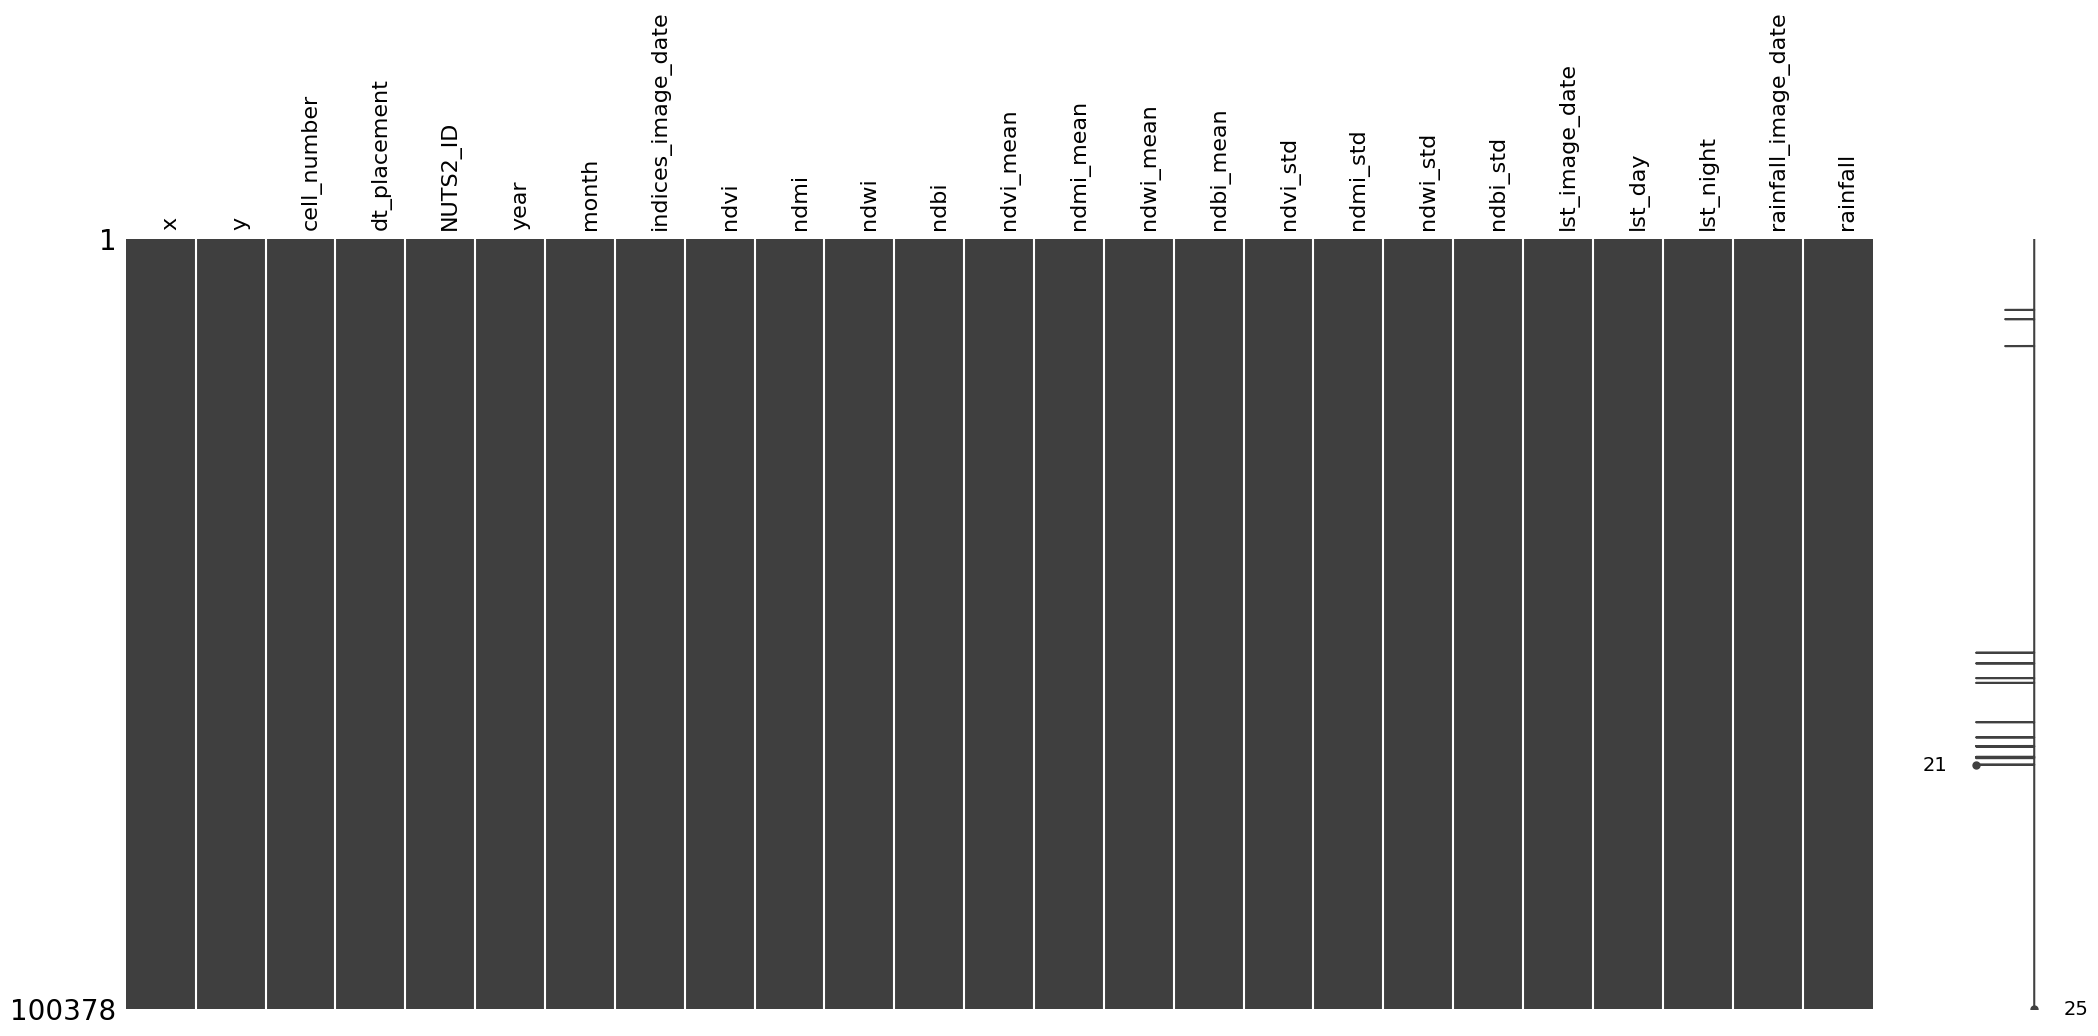

In [52]:
msno.matrix(df, label_rotation=90)

In [53]:
df2 = df.copy()

In [54]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

<Axes: >

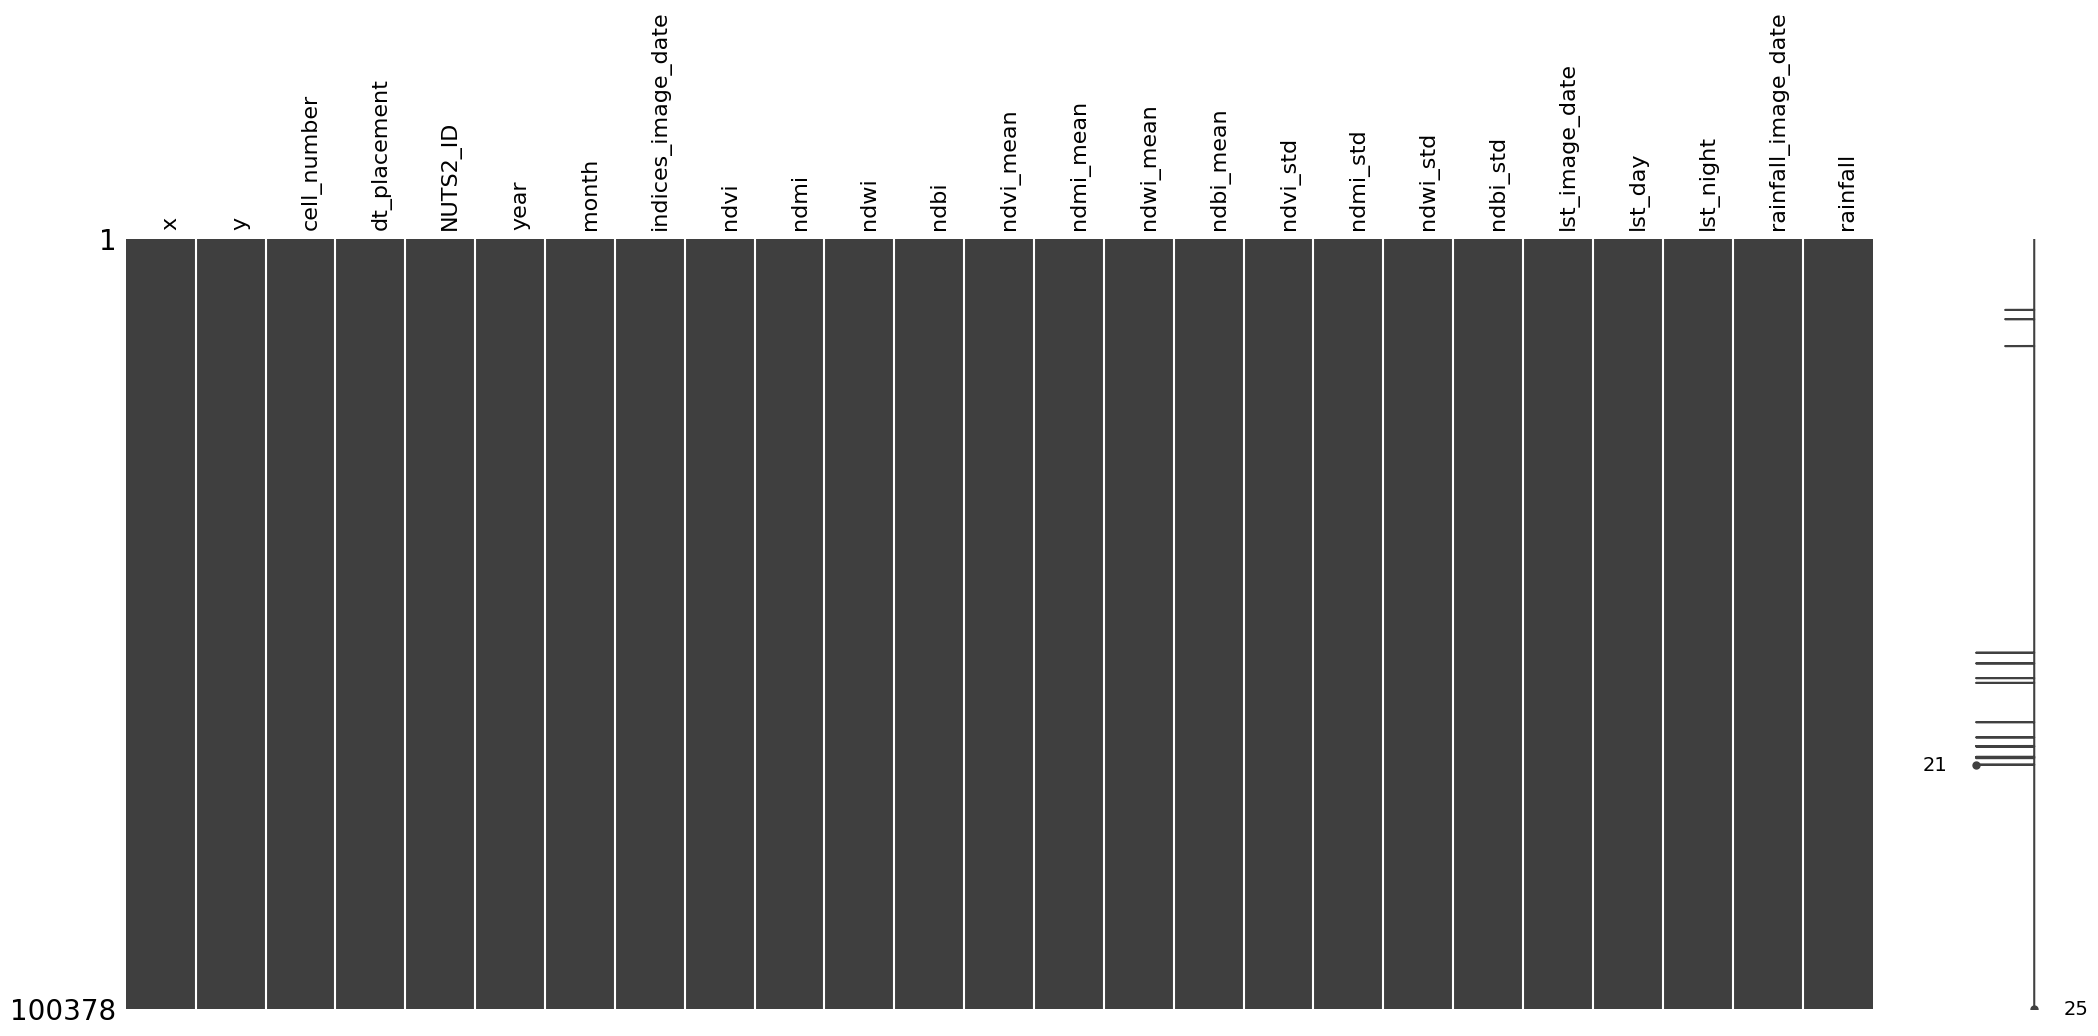

In [55]:
msno.matrix(df, label_rotation=90)

In [56]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
8,ndvi,0.0897
9,ndmi,0.0897
10,ndwi,0.0897
11,ndbi,0.0897
15,ndbi_mean,0.0120
19,ndbi_std,0.0120
21,lst_day,9.6774
22,lst_night,9.6774


In [57]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [58]:
df2.reset_index(drop=True, inplace=True)

In [59]:
df2

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,21.15549,39.67943,0,2024-05-02,EL61,2024,5,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,14703.0,13886.0,1.283924
1,21.15549,39.67943,0,2024-05-03,EL61,2024,5,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,14703.0,13675.0,0.000000
2,21.15549,39.67943,0,2024-05-04,EL61,2024,5,0.599134,0.259133,-0.525074,-0.259133,0.568781,0.239666,-0.494683,-0.239666,0.054665,0.102634,0.026389,0.102634,14703.0,13675.0,0.521945
3,21.15549,39.67943,0,2024-05-05,EL61,2024,5,0.629135,0.292248,-0.546083,-0.292248,0.562226,0.228036,-0.494274,-0.228036,0.054024,0.085745,0.041833,0.085745,14703.0,13902.0,0.000000
4,21.15549,39.67943,0,2024-05-06,EL61,2024,5,0.629135,0.292248,-0.546083,-0.292248,0.562226,0.228036,-0.494274,-0.228036,0.054024,0.085745,0.041833,0.085745,14744.0,13902.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100373,23.74369,39.10450,3233,2024-06-01,EL61,2024,6,0.568739,0.237624,-0.489304,-0.237624,0.587479,0.291392,-0.491882,-0.291392,0.071258,0.074697,0.041490,0.074697,NaN,NaN,0.000000
100374,23.90545,39.19433,3234,2024-06-01,EL61,2024,6,0.528387,0.153079,-0.454713,-0.153079,0.545313,0.171863,-0.468413,-0.171863,0.046762,0.048031,0.027824,0.048031,NaN,NaN,0.000000
100375,23.90545,39.21230,3235,2024-06-01,EL61,2024,6,0.529784,0.094728,-0.462851,-0.094728,0.483191,0.138257,-0.406922,-0.138257,0.017340,0.013679,0.022010,0.013679,NaN,NaN,0.000000
100376,23.92856,39.23027,3236,2024-06-01,EL61,2024,6,0.636646,0.251187,-0.517857,-0.251187,0.553087,0.185421,-0.475038,-0.185421,0.052659,0.051064,0.029595,0.051064,NaN,NaN,0.000000


In [60]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding='utf-8')